# 02 — Reproducing the status classification

The dashboard colors every site by lens: **Typical low** = 10th percentile of its record, **Worst case** = record minimum, mapped through the thresholds (anoxic < 0.1 < hypoxic < 1.4 < at-risk < 2.8 ≤ good).

Open-science check: recompute both lenses **from the raw inputs** using the very functions the site build imports, and compare against the committed `site_classification.csv`.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Locate the repo root from wherever this notebook is run
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "data" / "derived").exists())
DATA = ROOT / "data" / "derived"

def dtcol(df, c):
    """Coerce a column to tz-naive datetimes regardless of source format."""
    df[c] = pd.to_datetime(df[c], utc=True, format="mixed")              .dt.tz_localize(None)
    return df

print("repo root:", ROOT)
import sys
sys.path.insert(0, str(ROOT / "scripts"))
from build_status_map import class_of, QC_SUSPECT_ML_L
%matplotlib inline
print("QC rule (site: max plausible mL/L):", QC_SUSPECT_ML_L)

repo root: /home/claude/repo_check


QC rule (site: max plausible mL/L): {'CF226': 9.0}


In [2]:
cls = pd.read_csv(DATA / "site_classification.csv")
daily = dtcol(pd.read_csv(DATA / "site_daily.csv"), "date")
cf = dtcol(pd.read_csv(DATA / "cf_casts.csv"), "time")

rows = []
for code, g in daily.groupby("site_code"):          # continuous sites
    v = g.oxygen_ml_l.dropna()
    rows.append((code, class_of(v.quantile(.1)), class_of(v.min())))
for code, g in cf.groupby("site_code"):             # ship-visit sites
    lim = QC_SUSPECT_ML_L.get(code, np.inf)
    v = g.near_bottom_o2_ml_l[g.near_bottom_o2_ml_l <= lim].dropna()
    if len(v):
        rows.append((code, class_of(v.quantile(.1)), class_of(v.min())))
re = pd.DataFrame(rows, columns=["site_code", "re_exposure", "re_worst"])
cmp = cls.merge(re, on="site_code")
agree_e = (cmp.class_exposure == cmp.re_exposure)
agree_w = (cmp.class_worst_case == cmp.re_worst)
print(f"RESULT exposure_agree={agree_e.sum()}/{len(cmp)} "
      f"worst_agree={agree_w.sum()}/{len(cmp)}")
mism = cmp.loc[~(agree_e & agree_w),
    ["site_code", "class_exposure", "re_exposure",
     "class_worst_case", "re_worst", "o2_p10", "o2_min"]]
mism if len(mism) else "No mismatches - classification fully reproduced."

RESULT exposure_agree=43/43 worst_agree=43/43


'No mismatches - classification fully reproduced.'

Any mismatches above sit on threshold boundaries or reflect upstream QC choices (e.g. sensor-level flags applied before `site_daily.csv` was exported) — the point of publishing this check is that such differences are visible, not hidden.

## Spotlight: Saanich Inlet 2024 (SEVIP)

RESULT sevip2024_anoxic_days=14


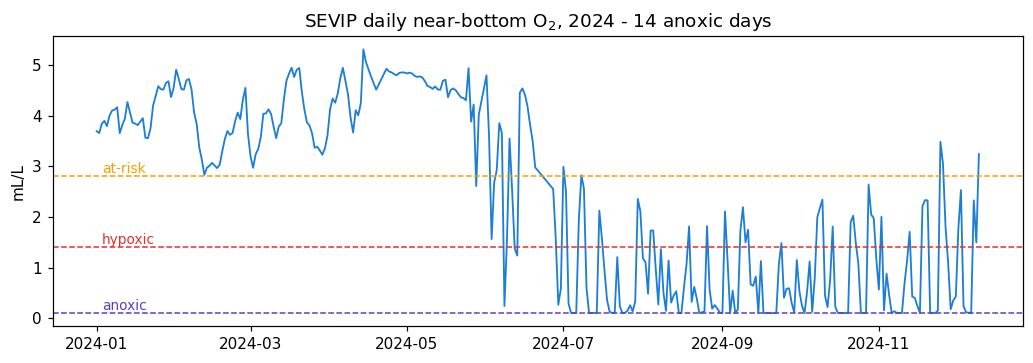

In [3]:
THRESHOLDS = {"anoxic": 0.1, "hypoxic": 1.4, "at_risk": 2.8}
COLORS = {"good": "#2f9e44", "at_risk": "#f59f00",
          "hypoxic": "#e03131", "anoxic": "#5f3dc4"}
sev = daily[(daily.site_code == "SEVIP") &
            (daily.date.dt.year == 2024)].sort_values("date")
fig, ax = plt.subplots(figsize=(9.5, 3.4), dpi=110)
ax.plot(sev.date, sev.oxygen_ml_l, lw=1.2, color="#1c7ed6")
for name, y, c in [("at-risk", 2.8, COLORS["at_risk"]),
                   ("hypoxic", 1.4, COLORS["hypoxic"]),
                   ("anoxic", 0.1, COLORS["anoxic"])]:
    ax.axhline(y, ls="--", lw=1, color=c)
    ax.text(sev.date.iloc[2], y + .06, name, color=c, fontsize=9)
anx = int((sev.oxygen_ml_l < 0.1).sum())
ax.set(title=f"SEVIP daily near-bottom O$_2$, 2024 - "
             f"{anx} anoxic days", ylabel="mL/L")
plt.tight_layout()
print(f"RESULT sevip2024_anoxic_days={anx}")